# 05 — Host-mass comparison with $R_{200c}$ cut, **TNG median-SFMS quenching**

Identical analysis to `05_compare_hostmass_radiuscut.ipynb` — overlay host halo-mass windows
(12.0–12.5, >12, 12.0–13.5, >13.5), within $1\,R_{200c}$, fitting the anisotropy
$p(\theta)\propto1+A\cos2\theta$ and the quench fraction $f_q(\theta)=a+b\cos2\theta$ — but it reads
the catalog built by `01_generate_catalogs_massive_tngsfms.ipynb`, whose `quenched` flag is defined
relative to **the simulation's own median SFMS** (not the fixed SDSS relation).

That catalog also carries the old `quenched_sdss` flag, so the **fit summary shows `b` under both
definitions side by side** — the direct test of whether switching to the TNG SFMS moves the
quench-anisotropy amplitude (e.g. back toward the A&A 2025 value of $b\approx+0.016$ within $R_{200c}$).

`QUENCH_COL` selects which flag drives the $f_q$ figure (default the TNG one). Radius cut, host
windows, redshift, and satellite cuts stay flexible. Missing catalogs/columns are handled gracefully.

In [12]:
import os, warnings
import numpy as np
import pandas as pd
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# ================= CONFIG — change these and re-run =================
DATA_ROOT = "../data2"
BASE_CAT  = "tng_satellites_hostlogM12.0plus_logM7.00.csv"   # from 01_generate_catalogs_massive_tngsfms

REDZ         = "z0"            # "z0" (z=0) or "z0p05" (z=0.05)
RADIUS_CUT   = True           # this is the within-R200c version
R200C_FACTOR = 1.0            # aperture in R_200c

QUENCH_COL   = "quenched"       # which flag drives the f_q figure: "quenched" (TNG SFMS) or "quenched_sdss"
SDSS_COL     = "quenched_sdss"  # the comparison column (skipped if absent)

# what each panel shows: (sim, satellite log10 M* cut, _)
PANELS = [
    ("tng100", 8.0, None),        # TNG100: M*_sat > 1e8
    ("tng50",  7.0, None),        # TNG50:  M*_sat > 1e7
]
# host-mass windows to overlay: (label, (min, max) log10 M200c; None = open, color, linestyle)
HOST_VARIANTS = [
    ("12.0-12.5", (12.0, 12.5), "#1f77b4", "-"),
    (">12",       (12.0, 14.2), "#2ca02c", "--"),
    ("12.0-13.5", (12.0, 13.5), "#ff7f0e", "-."),
    (">13.5",     (13.5, 14.2), "#d62728", ":"),
]
# ===================================================================

N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])

_rc = f"within {R200C_FACTOR:g} R200c" if RADIUS_CUT else "no radius cut"
print(f"z: {REDZ} | radius: {_rc} | quench flag: {QUENCH_COL} | host windows: {[v[0] for v in HOST_VARIANTS]}")

z: z0 | radius: within 1 R200c | quench flag: quenched | host windows: ['12.0-12.5', '>12', '12.0-13.5', '>13.5']


## Helpers — $P(\theta)$, the $A$ fit, and the quench-fraction sinusoid

Identical to `notebooks2/03`, `04`, `05`.

In [13]:
def norm_hist(theta):
    c, _ = np.histogram(theta, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def model_curve(A):
    x = np.linspace(0, 90, 200)
    return x, (1.0 / 90.0) * (1.0 + A * np.cos(2 * np.radians(x)))

def fit_anisotropy(theta_deg, n_walkers=16, n_steps=4000, burn=1000, seed=0):
    '''MCMC of p(theta) ~ 1 + A cos(2 theta). Returns dict with A median/std/percentiles.'''
    th = np.radians(np.asarray(theta_deg, dtype=float))
    c2 = np.cos(2 * th); n = len(th)
    if n < 5:
        return dict(n=n, A=np.nan, Aerr=np.nan, lo=np.nan, hi=np.nan)

    def log_prob(p):
        A = p[0]
        if not (-0.999 < A < 0.999):
            return -np.inf
        v = 1.0 + A * c2
        if np.any(v <= 0):
            return -np.inf
        return np.sum(np.log(v))

    rng = np.random.default_rng(seed)
    p0 = rng.uniform(-0.1, 0.1, size=(n_walkers, 1))
    sampler = emcee.EnsembleSampler(n_walkers, 1, log_prob)
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)[:, 0]
    lo, med, hi = np.percentile(chain, [16, 50, 84])
    return dict(n=n, A=med, Aerr=chain.std(), lo=lo, hi=hi)

def bootstrap_fq(angle, quenched, N=5000, seed=0):
    '''Binned-mean quench fraction per angle bin, bootstrap mean and 1-sigma error.'''
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def _fq_log_prob(theta, x, y, sigma):
    a, b, f = theta
    if not (0 < a < 1 and -1 < b < 1 and -10 < f < 2):
        return -np.inf
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def fit_fq_sinusoid(mean, std, n_walkers=20, n_steps=6000, burn=1000, seed=0):
    '''MCMC fit of f_q = a + b cos(2 theta); returns (params_mean, params_std).'''
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    if ok.sum() < 4:
        return np.array([np.nan] * 3), np.array([np.nan] * 3)
    p0 = np.array([0.5, 0.0, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, _fq_log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

def fq_band(p, e, n_mc=5000, seed=0):
    '''Posterior median + 16/84th-percentile band of f_q over [0, 90].'''
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 300)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    yy = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    return np.degrees(x), a.mean() + b.mean() * np.cos(2 * x), np.percentile(yy, 16, 0), np.percentile(yy, 84, 0)

def fit_fq_for(angle, flag):
    '''Bootstrap + sinusoid fit for a given quench flag array; returns (mean, std, p, e).'''
    m, s = bootstrap_fq(angle, flag)
    p, e = fit_fq_sinusoid(m, s)
    return m, s, p, e

## Load every (simulation, host-mass window) and fit both quench definitions

Post-select each host window, the panel's satellite floor, and the $R_{200c}$ cut. The anisotropy
`A` is fit once (independent of quench flag). The quench `b` is fit for the `QUENCH_COL` flag (TNG
SFMS) and, when the catalog has it, also for `SDSS_COL` — enabling the side-by-side comparison.

In [14]:
def load_sel(sim, logcut, window):
    path = os.path.join(DATA_ROOT, sim, REDZ, BASE_CAT)
    if not os.path.exists(path):
        print(f"[skip] missing {path}")
        return None
    df = pd.read_csv(path)
    hlo, hhi = window
    if hlo is not None: df = df[df["host_m200_phys"] > hlo]
    if hhi is not None: df = df[df["host_m200_phys"] < hhi]
    df = df[df["mstar_phys"] > logcut]
    if RADIUS_CUT:
        df = df[df["d_r200_3d"] < R200C_FACTOR]
    return df

data, fits = {}, {}
fq_mean, fq_std, fq_p, fq_e = {}, {}, {}, {}        # for QUENCH_COL (drives the figure)
fq_p_sdss, fq_e_sdss = {}, {}                        # for SDSS_COL (comparison table)
HAVE_SDSS = False

print(f"{'dataset':<10s} {'host window':<12s} {'hosts':>6s} {'sats':>7s} {'f_q':>7s}")
for sim, logcut, _ in PANELS:
    for hlabel, window, _, _ in HOST_VARIANTS:
        df = load_sel(sim, logcut, window)
        if df is None or len(df) == 0:
            print(f"{sim:<10s} {hlabel:<12s}  (no satellites after selection)")
            continue
        key = (sim, hlabel)
        theta = df["alpha"].to_numpy()
        data[key] = theta
        fits[key] = fit_anisotropy(theta, seed=1)
        m, s, p, e = fit_fq_for(theta, df[QUENCH_COL].to_numpy(dtype=float))
        fq_mean[key], fq_std[key], fq_p[key], fq_e[key] = m, s, p, e
        if SDSS_COL in df.columns:
            HAVE_SDSS = True
            _, _, ps, es = fit_fq_for(theta, df[SDSS_COL].to_numpy(dtype=float))
            fq_p_sdss[key], fq_e_sdss[key] = ps, es
        print(f"{sim:<10s} {hlabel:<12s} {df['host_id'].nunique():>6d} {len(df):>7d} {df[QUENCH_COL].mean():>7.3f}")
if not HAVE_SDSS:
    print(f"\n(note: '{SDSS_COL}' not in catalog -> showing only the {QUENCH_COL} fit)")

dataset    host window   hosts    sats     f_q
tng100     12.0-12.5       867    2165   0.364
tng100     >12            1320    9866   0.668
tng100     12.0-13.5      1281    7087   0.583
tng100     >13.5            39    2779   0.885
tng50      12.0-12.5       116     945   0.580
tng50      >12             163    3345   0.776
tng50      12.0-13.5       158    2415   0.722
tng50      >13.5             5     930   0.917

(note: 'quenched_sdss' not in catalog -> showing only the quenched fit)


## Fit summary — anisotropy $A$, and quench $b$ under both definitions

`b (TNG)` uses the median-SFMS `quenched` flag; `b (SDSS)` uses the fixed-SDSS `quenched_sdss`
flag. Compare the sign and significance across host-mass windows.

In [15]:
hdr = f"{'dataset':<10s} {'host window':<12s} {'N':>6s}  {'A':>14s}  {'b (TNG)':>16s}"
if HAVE_SDSS:
    hdr += f"  {'b (SDSS)':>16s}"
print(hdr)
for sim, logcut, _ in PANELS:
    for hlabel, window, _, _ in HOST_VARIANTS:
        key = (sim, hlabel)
        if key not in fits:
            continue
        f = fits[key]; p, e = fq_p[key], fq_e[key]
        bsig = abs(p[1] / e[1]) if np.isfinite(p[1]) else np.nan
        row = (f"{sim:<10s} {hlabel:<12s} {f['n']:>6d}  {f['A']:+.3f}+/-{f['Aerr']:.3f}  "
               f"{p[1]:+.3f}+/-{e[1]:.3f}({bsig:.1f})")
        if HAVE_SDSS and key in fq_p_sdss:
            ps, es = fq_p_sdss[key], fq_e_sdss[key]
            ssig = abs(ps[1] / es[1]) if np.isfinite(ps[1]) else np.nan
            row += f"  {ps[1]:+.3f}+/-{es[1]:.3f}({ssig:.1f})"
        print(row)

dataset    host window       N               A           b (TNG)
tng100     12.0-12.5      2165  +0.223+/-0.030  -0.038+/-0.015(2.5)
tng100     >12            9866  +0.241+/-0.014  -0.016+/-0.007(2.3)
tng100     12.0-13.5      7087  +0.212+/-0.016  -0.039+/-0.009(4.6)
tng100     >13.5          2779  +0.315+/-0.025  +0.024+/-0.009(2.5)
tng50      12.0-12.5       945  +0.189+/-0.046  -0.057+/-0.023(2.4)
tng50      >12            3345  +0.181+/-0.024  -0.035+/-0.010(3.4)
tng50      12.0-13.5      2415  +0.152+/-0.029  -0.057+/-0.012(4.6)
tng50      >13.5           930  +0.252+/-0.044  +0.002+/-0.014(0.1)


### Figure 1 — anisotropy $P(\theta)$ across host-mass windows (overlaid)

One panel per simulation; each host window is a color. Faint step = $P(\theta)$; bold curve =
posterior-median $\tfrac{1}{90}(1+A\cos2\theta)$; dotted line = isotropic level. (Independent of the
quench definition.)

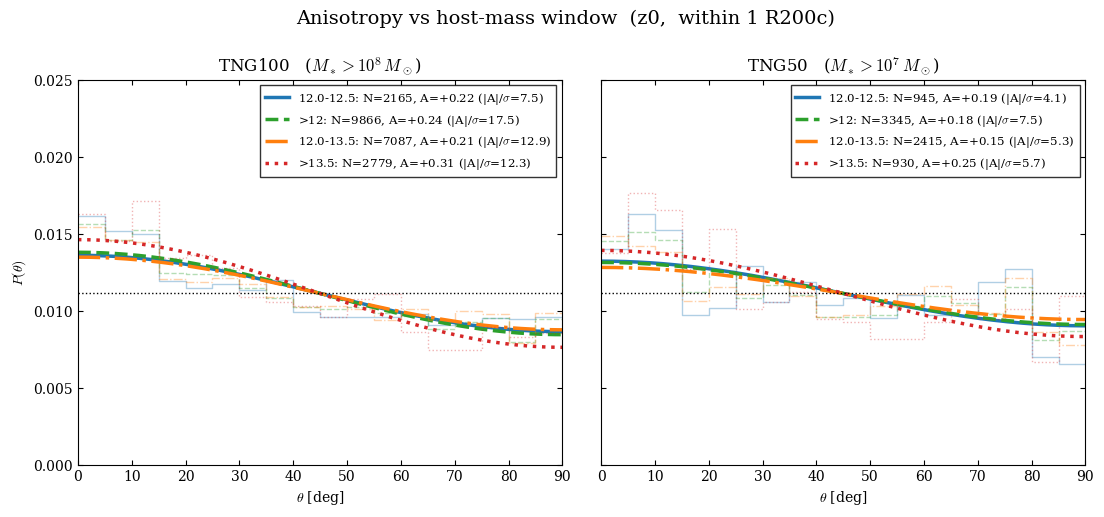

In [16]:
SATLABEL = {8.0: r"$M_* > 10^8\,M_\odot$", 7.0: r"$M_* > 10^7\,M_\odot$"}
_sup = f"{REDZ},  {_rc}"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut, _) in zip(axes, PANELS):
    for hlabel, window, color, ls in HOST_VARIANTS:
        key = (sim, hlabel)
        if key not in fits:
            continue
        f = fits[key]; h = norm_hist(data[key])
        ax.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=color, ls=ls, lw=1.0, alpha=0.35)
        if np.isfinite(f["A"]):
            x, y = model_curve(f["A"])
            ax.plot(x, y, color=color, ls=ls, lw=2.5,
                    label=f"{hlabel}: N={f['n']}, A={f['A']:+.2f} (|A|/$\\sigma$={abs(f['A']/f['Aerr']):.1f})")
    ax.axhline(1 / 90, color="k", lw=1, ls=":")
    ax.set_xlim(0, 90); ax.set_ylim(0, 0.025)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.legend(fontsize=8.5, fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$P(\theta)$")
fig.suptitle(f"Anisotropy vs host-mass window  ({_sup})", y=1.02, fontsize=14)
plt.subplots_adjust(wspace=0.08); plt.show()

### Figure 2 — quench fraction $f_q(\theta)$ across host-mass windows (overlaid)

Using the **`QUENCH_COL`** flag (TNG median-SFMS by default). Points = bootstrap $f_q$ (thin
errorbars); bold line + band = MCMC posterior median and 16–84th percentile.

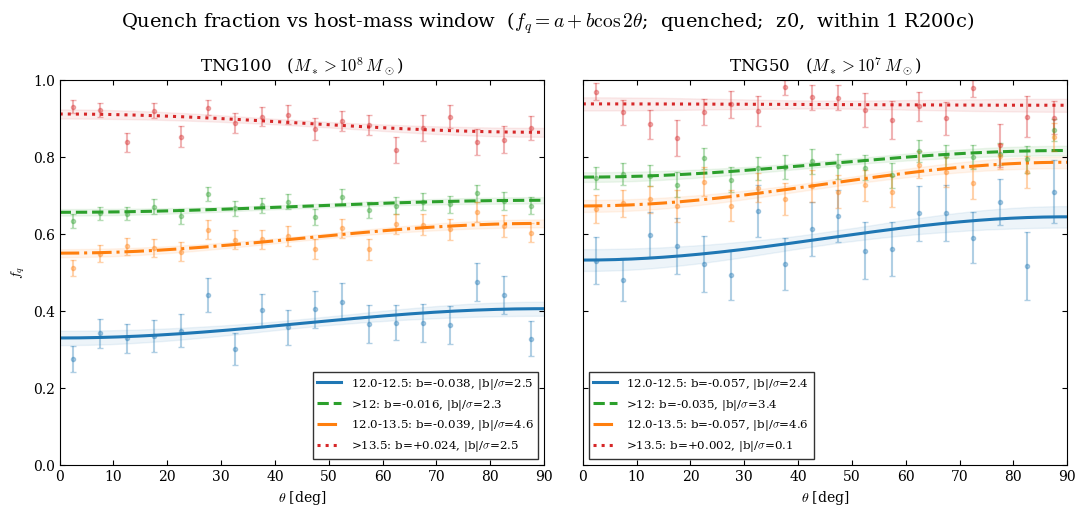

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut, _) in zip(axes, PANELS):
    for hlabel, window, color, ls in HOST_VARIANTS:
        key = (sim, hlabel)
        if key not in fq_p:
            continue
        m, s = fq_mean[key], fq_std[key]
        p, e = fq_p[key], fq_e[key]
        sig = abs(p[1] / e[1]) if np.isfinite(p[1]) else np.nan
        ax.errorbar(ANGLE_CENTERS, m, yerr=s, fmt="o", color=color, capsize=2, ms=3, ls="none", alpha=0.35)
        if np.isfinite(p[1]):
            x, ymed, ylo, yhi = fq_band(p, e)
            ax.plot(x, ymed, color=color, ls=ls, lw=2.2,
                    label=f"{hlabel}: b={p[1]:+.3f}, |b|/$\\sigma$={sig:.1f}")
            ax.fill_between(x, ylo, yhi, color=color, alpha=0.08)
    ax.set_xlim(0, 90); ax.set_ylim(0, 1)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.legend(fontsize=8.5, fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$f_q$")
fig.suptitle(f"Quench fraction vs host-mass window  ($f_q=a+b\\cos2\\theta$;  {QUENCH_COL};  {_sup})",
             y=1.02, fontsize=14)
plt.subplots_adjust(wspace=0.08); plt.show()